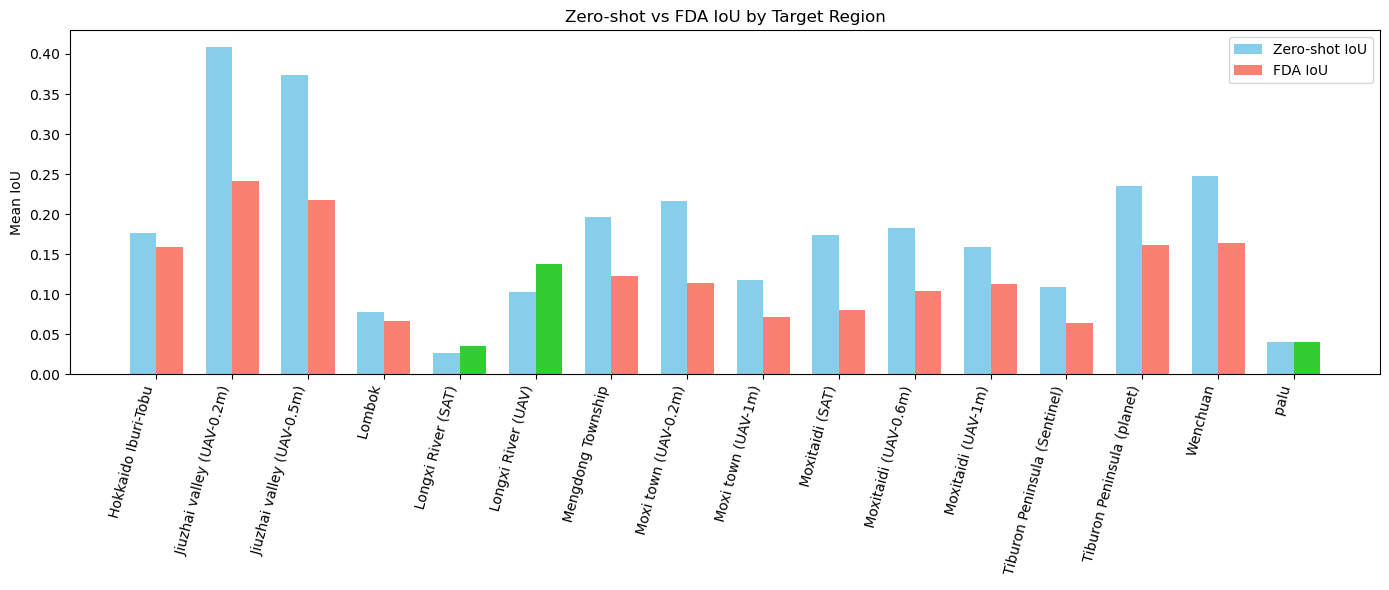

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

zero = pd.read_csv("../../results/baseline/source_only_100.csv")
fda = pd.read_csv("../../results/new_fda/01.csv")

zero = zero.add_suffix("_zero")
fda = fda.add_suffix("_fda")

merged = pd.merge(
    zero,
    fda,
    left_on=["source_region_zero", "target_region_zero"],
    right_on=["source_region_fda", "target_region_fda"],
    how="inner"
)

merged["pair"] = merged["source_region_zero"] + " → " + merged["target_region_zero"]
merged["iou_zero"] = merged["iou_zero"]
merged["iou_fda"] = merged["iou_fda"]

grouped = merged.groupby("target_region_zero")[["iou_zero", "iou_fda"]].mean().reset_index()

grouped["better_fda"] = grouped["iou_fda"] > grouped["iou_zero"]

plt.figure(figsize=(14, 6))
bar_width = 0.35
x = range(len(grouped))

plt.bar([i - bar_width/2 for i in x],
        grouped["iou_zero"], width=bar_width, label="Zero-shot IoU", color="skyblue")

colors = ["limegreen" if b else "salmon" for b in grouped["better_fda"]]
plt.bar([i + bar_width/2 for i in x],
        grouped["iou_fda"], width=bar_width, label="FDA IoU", color=colors)

plt.xticks(x, grouped["target_region_zero"], rotation=75, ha="right")
plt.ylabel("Mean IoU")
plt.title("Zero-shot vs FDA IoU by Target Region")
plt.legend()
plt.tight_layout()
plt.show()
